In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

In [2]:
df = pd.read_csv('../data/online_retail.csv', encoding='ISO-8859-1')
df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [3]:
# Eliminar nulos en clientes
df = df.dropna(subset=['CustomerID'])

# Convertir fecha
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Crear tipo de transacción (COMPRA / DEVOLUCIÓN)
df['TransactionType'] = df['Quantity'].apply(lambda x: 'Return' if x < 0 else 'Purchase')

# Cantidad absoluta
df['AbsQuantity'] = df['Quantity'].abs()

# Total de venta
df['TotalPrice'] = df['AbsQuantity'] * df['UnitPrice']

In [4]:
df.head

<bound method NDFrame.head of        InvoiceNo StockCode                          Description  Quantity  \
0         536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1         536365     71053                  WHITE METAL LANTERN         6   
2         536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3         536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4         536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
...          ...       ...                                  ...       ...   
541904    581587     22613          PACK OF 20 SPACEBOY NAPKINS        12   
541905    581587     22899         CHILDREN'S APRON DOLLY GIRL          6   
541906    581587     23254        CHILDRENS CUTLERY DOLLY GIRL          4   
541907    581587     23255      CHILDRENS CUTLERY CIRCUS PARADE         4   
541908    581587     22138        BAKING SET 9 PIECE RETROSPOT          3   

               InvoiceDate  UnitPrice  Custom

In [5]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TransactionType,AbsQuantity,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,Purchase,6,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,Purchase,6,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,Purchase,8,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,Purchase,6,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,Purchase,6,20.34
...,...,...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,Purchase,12,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,Purchase,6,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,Purchase,4,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,Purchase,4,16.60


In [7]:
#Separar Datos de Compra y Devolución
sales = df[df['TransactionType'] == 'Purchase']
returns = df[df['TransactionType'] == 'Return']

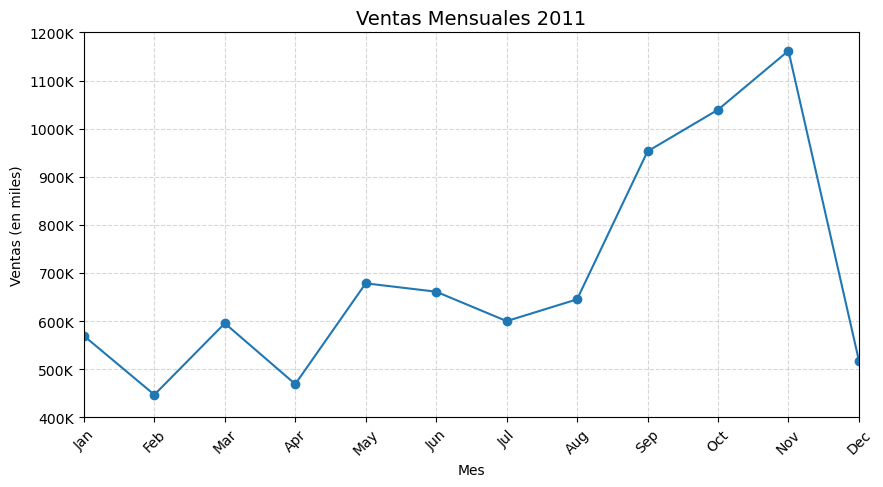

In [19]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Convertir índice a fecha
monthly_sales_2011.index = monthly_sales_2011.index.to_timestamp()

fig, ax = plt.subplots(figsize=(10,5))

# Gráfica
monthly_sales_2011.plot(marker='o', ax=ax)

# 🎯 Título y etiquetas
ax.set_title('Ventas Mensuales 2011', fontsize=14)
ax.set_xlabel('Mes')
ax.set_ylabel('Ventas (en miles)')

# 🎯 Formato eje Y (en miles)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x/1000)}K'))

# 🎯 Control del rango (MUY IMPORTANTE)
ax.set_ylim(400000, 1200000)

# 🎯 Intervalos del eje Y (cada 100K)
ax.yaxis.set_major_locator(ticker.MultipleLocator(100000))

# 🎯 Mejorar eje X
ax.set_xticks(monthly_sales_2011.index)
ax.set_xticklabels(monthly_sales_2011.index.strftime('%b'), rotation=45)

# 🎯 Grid para lectura fácil
ax.grid(True, linestyle='--', alpha=0.5)

plt.savefig('../imagenes/ventas_mensuales_2011.png', dpi=300, bbox_inches='tight')
plt.show()

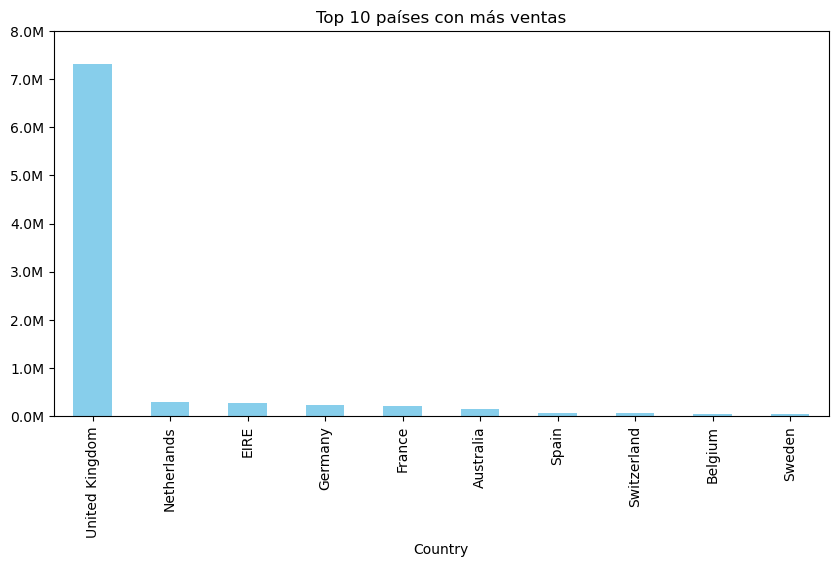

In [26]:
# Ventas por país
country_sales = sales.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)

ax =country_sales.plot(kind='bar', title='Top 10 países con más ventas', figsize=(10,5), color='skyblue')
ax.set_ylim(0, 8000000)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1_000_000:.1f}M'))
plt.savefig('../imagenes/ventas_paises.png')
plt.show()